In [1]:
import pandas as pd
import glob

In [2]:
glob_path = "./data/*.csv"

In [3]:
glob_path

'./data/*.csv'

In [4]:
glob_list = glob.glob(glob_path)

In [5]:
df = pd.read_csv(glob_list[0])

C:\Users\Kunal\AppData\Local\Temp\ipykernel_20300\547912625.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(glob_list[0])


In [6]:
# Data Cleaning

df.isnull().sum()

Invoice           0
StockCode      3350
Description       0
Quantity          0
Price             0
Country           0
cust_id           0
total_price       0
R_days            0
date              0
time              0
dtype: int64

In [7]:
df.isna().sum()

Invoice           0
StockCode      3350
Description       0
Quantity          0
Price             0
Country           0
cust_id           0
total_price       0
R_days            0
date              0
time              0
dtype: int64

In [8]:
df.size

8776735

In [9]:
df.describe()

,Quantity,Price,cust_id,total_price,R_days
count,797885.000000,797885.000000,797885.000000,797885.000000,797885.000000
mean,12.602980,3.702732,15313.062777,20.416465,340.444921
std,191.670371,71.392549,1696.466663,313.518824,220.758207
min,-80995.000000,0.000000,12346.000000,-168469.600000,0.000000
25%,2.000000,1.250000,13964.000000,4.350000,130.000000
50%,5.000000,1.950000,15228.000000,11.700000,372.000000
75%,12.000000,3.750000,16788.000000,19.500000,525.000000
max,80995.000000,38970.000000,18287.000000,168469.600000,738.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797885 entries, 0 to 797884
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      797885 non-null  object 
 1   StockCode    794535 non-null  object 
 2   Description  797885 non-null  object 
 3   Quantity     797885 non-null  int64  
 4   Price        797885 non-null  float64
 5   Country      797885 non-null  object 
 6   cust_id      797885 non-null  int64  
 7   total_price  797885 non-null  float64
 8   R_days       797885 non-null  int64  
 9   date         797885 non-null  object 
 10  time         797885 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 67.0+ MB


In [11]:
# Revenue

# Total Revenue
# Revenue trend (daily/weekly/monthly)
# Average Order Value (AOV)

# Customers

# New vs Returning customers
# Customer Lifetime Value (basic version is fine)
# Top customers

# Products

# Top selling products
# Low-performing products
# Category performance

# Operations

# Order volume trends
# Refund / cancellation rate (if data exists)
# 📈 Dashboard Views

# Think like a founder who has 5 mins, not an analyst.

# Revenue trend line
# Top products bar chart
# Customer segmentation pie
# Orders over time
# Heatmap (optional advanced)

In [12]:
# Revenue

# Total Revenue
# Revenue trend (daily/weekly/monthly)
# Average Order Value (AOV)

In [13]:
df.head()

,Invoice,StockCode,Description,Quantity,Price,Country,cust_id,total_price,R_days,date,time
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,United Kingdom,13085,83.4,738,2009-12-01,07:45:00
1,489434,79323,PINK CHERRY LIGHTS,12,6.75,United Kingdom,13085,81.0,738,2009-12-01,07:45:00
2,489434,79323,WHITE CHERRY LIGHTS,12,6.75,United Kingdom,13085,81.0,738,2009-12-01,07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,United Kingdom,13085,100.8,738,2009-12-01,07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,United Kingdom,13085,30.0,738,2009-12-01,07:45:00


In [14]:
total_revenue = df['total_price'].sum()

In [15]:
print(f"${(total_revenue)/1000000:.2f}M")

$16.29M


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#### Date filters

df['date'] = pd.to_datetime(df['date'])

In [18]:
class DateFilter:
    def __init__(self, df, filter_type=None, filter_data=None, token=None):
        self.df = df
        self.filter_type = filter_type
        self.filter_data = filter_data
        self.token = token

    def apply(self):
        
        if not self.filter_type or not self.filter_data or not self.token:
            return self.df  # nothing to apply

        # map filter type → pandas datetime accessor
        attr_map = {
            "year": "year",
            "month": "month",
            "day": "day"
        }

        attr = attr_map.get(self.filter_type)

        if not attr:
            return self.df

        series = getattr(self.df['date'].dt, attr)

        if self.token == "between":
            start, end = self.filter_data
            return self.df[(series >= start) & (series <= end)]

        elif self.token == "more":
            return self.df[series >= self.filter_data[0]]

        elif self.token == "less":
            return self.df[series <= self.filter_data[0]]

        return self.df

In [19]:
filters = [
    {"type": "year", "data": [2009], "token": "more"},
    {"type": "month", "data": [1, 6], "token": "between"},
    {"type": "day", "data": [1, 15], "token": "between"},
]

In [20]:
df.size

8776735

In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,Price,Country,cust_id,total_price,R_days,date,time
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,United Kingdom,13085,83.4,738,2009-12-01,07:45:00
1,489434,79323,PINK CHERRY LIGHTS,12,6.75,United Kingdom,13085,81.0,738,2009-12-01,07:45:00
2,489434,79323,WHITE CHERRY LIGHTS,12,6.75,United Kingdom,13085,81.0,738,2009-12-01,07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,United Kingdom,13085,100.8,738,2009-12-01,07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,United Kingdom,13085,30.0,738,2009-12-01,07:45:00


In [22]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Netherlands', 'Poland',
       'Spain', 'Channel Islands', 'Italy', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland',
       'Switzerland', 'Unspecified', 'Nigeria', 'Malta', 'RSA',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

In [23]:
country = ['Canada', 'Germany']
def country_filter(df, country):
    if not country:
        return df
    return df[df['Country'].isin(country)]

In [24]:
product = []

def product_filter(df, product):
    if not product:
        return df
    return df[df['Description'].isin(product)]

In [25]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    5149
REGENCY CAKESTAND 3 TIER              3678
JUMBO BAG RED RETROSPOT               2713
ASSORTED COLOUR BIRD ORNAMENT         2709
PARTY BUNTING                         2121
                                      ... 
HEN PARTY BANNER TAPE                    1
SPOTTY COCKEREL DOORSTOP                 1
S/3 ROSE GARDEN SCENT SQU CANDLE         1
RUSSIAN FOLKART STACKING TINS            1
VINTAGE METAL CAKE STAND CREAM           1
Name: count, Length: 5299, dtype: int64

In [26]:
# Apply filters

filters = [
    {"type" : "product", "data" : ['WHITE HANGING HEART T-LIGHT HOLDER', 'REGENCY CAKESTAND 3 TIER', 'PARTY BUNTING', 'ASSORTED COLOUR BIRD ORNAMENT', 'STRAWBERRY CERAMIC TRINKET BOX']},
    {"type" : "country", "data" : ['Canada', 'Germany']},
    {"type": "year", "data": [2009], "token": "more"},
    {"type": "month", "data": [1, 6], "token": "between"},
    {"type": "day", "data": [1, 15], "token": "between"},
]

In [27]:
filter_map = {
    "product" : product_filter,
    "country" : country_filter,
}

In [28]:
def apply_filters(df, filters):
    df = df.copy()  # avoid modifying original df
    df['date'] = pd.to_datetime(df['date'])  # ensure date is datetime
    for i in filters:
        type =i['type']
        data = i['data']

        if type in filter_map:
            filter_func = filter_map[type]
            df = filter_func(df, data)
            
        elif type in ["year", "month", "day"]:
            token = i['token']
            date_filter = DateFilter(df, filter_type=type, filter_data=data, token=token)
            df = date_filter.apply()

    return df

In [29]:
updated_df = apply_filters(df, filters)

In [30]:
updated_df.head()

,Invoice,StockCode,Description,Quantity,Price,Country,cust_id,total_price,R_days,date,time
35562,494009,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,Germany,12471,30.00,697,2010-01-11,08:51:00
36095,494170,84879,ASSORTED COLOUR BIRD ORNAMENT,16,1.69,Germany,12600,27.04,696,2010-01-12,10:36:00
38260,C494474,21232,STRAWBERRY CERAMIC TRINKET BOX,-3,1.25,Germany,12471,-3.75,693,2010-01-14,15:06:00
60052,497340,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,Germany,12665,30.00,668,2010-02-08,15:11:00
60481,497371,21232,STRAWBERRY CERAMIC TRINKET BOX,12,1.25,Germany,12471,15.00,668,2010-02-09,10:24:00


In [31]:
ui = input("enter list")
ui = ui.replace(" ","")
ui = ui.split(",")

<Axes: xlabel='date', ylabel='total_price'>

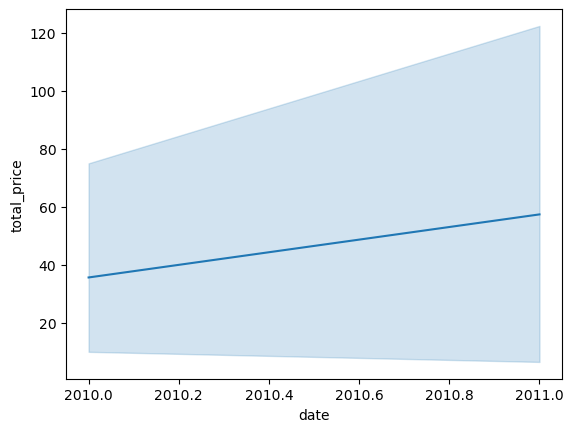

In [32]:
sns.lineplot(data = updated_df, x = updated_df['date'].dt.year, y="total_price")

In [80]:
def date_wise_trends(df, date_part, on = None, metric = None):
    attr_map = {
        "year": "year",
        "month": "month",
        "day": "day"
    }

    attr = attr_map.get(date_part)

    # Extract the date part properly
    df[date_part] = getattr(df['date'].dt, attr)

    year_group = (
        df.groupby(date_part)
        .agg({on : metric})
        .reset_index()
        .sort_values(date_part, ascending=True)
    )

    year_group[date_part] = year_group[date_part].astype(str)



    sns.lineplot(data=year_group, x=date_part, y=on)

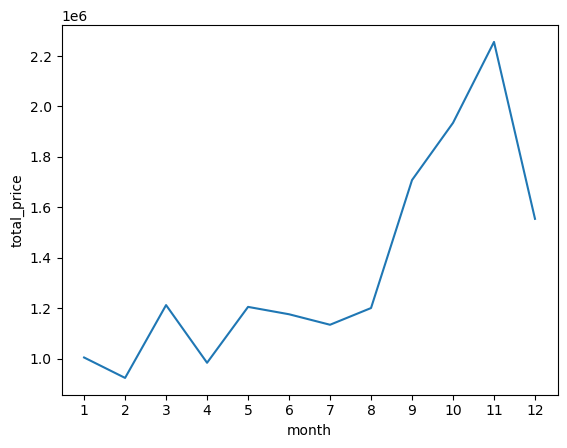

In [34]:
date_wise_trends(df, "month")

In [35]:
## Average Order Value (AOV)
aov = f"{(total_revenue / df['Invoice'].nunique()):.2f}"

In [36]:
aov

'363.00'

In [37]:
#Customers
# 1. New Vs Returning

cust_seg = df.groupby('cust_id').agg({
    "date":"nunique"
}).reset_index().sort_values("date", ascending=False)


cust_seg['segment'] = cust_seg['date'].apply(lambda x: 'New' if x == 1 else 'Returning')

new_cust = (cust_seg[cust_seg['segment'] == 'New'].shape[0] / cust_seg.shape[0]) * 100
returning_cust = (cust_seg[cust_seg['segment'] == 'Returning'].shape[0] / cust_seg.shape[0]) * 100


In [38]:
new_cust

25.98451699764389

In [39]:
returning_cust

74.0154830023561

In [49]:
# Customer Lifetime Value

# CLV = purchase_frequency * average_order_value * customer_lifespan

# customer_lifespan = 1/churn_rate


# churn_rate = (customer_lost/ customer_at_beginning_of_period)


### Churn Rate Calculation

year = 2010

filters = [
    {"type": "year", "data": [2010], "token": "less"}
]

for i in filters:
    type =i['type']
    data = i['data']
    token = i['token']

    date_filter = DateFilter(df, filter_type=type, filter_data=data, token=token)
    req_cust = date_filter.apply()

customer_after_period = df[df['date'].dt.year > year]

cust_before = set(req_cust['cust_id'].unique())
cust_after = set(customer_after_period['cust_id'].unique())


customer_lost = len(cust_before - cust_after)
churn_rate = (customer_lost / len(cust_before))
average_lifespan = 1/(churn_rate)



In [50]:
average_lifespan

2.5989399293286217

In [51]:
purchase_frequency = df.groupby('cust_id')['Invoice'].nunique().mean()

In [52]:
purchase_frequency

7.552339279703803

In [59]:
customer_life_time_value = float(f"{(purchase_frequency * float(aov) * average_lifespan):.2f}")

In [60]:
customer_life_time_value

7124.99

In [63]:
#Top / Bottom N Customers

top_or_bottom = None
n = None
on = None
metric = None

def top_bottom_customers(df, top_or_bottom = None, n = None, on = None, metric = None):
    if not top_or_bottom or not n or not on or not metric:
        return df
    
    cust_revenue = df.groupby(on).agg({
        metric : "sum"
    }).sort_values(metric, ascending = False)

    if top_or_bottom == "top":
        return cust_revenue.head(n)
    
    elif top_or_bottom == "bottom":
        return cust_revenue.tail(n)

In [66]:
top_bottom_customers(df, top_or_bottom="top", n = 10, on = "cust_id", metric = "total_price")

,total_price
cust_id,
18102,570380.61
14646,523342.07
14156,296063.44
14911,265757.91
17450,231390.55
13694,190020.84
17511,168491.62
12415,143269.29
16684,141502.25


In [73]:
#Refund rate

def refund_rate(df):
    total_orders= df['Invoice'].nunique()
    refunded_orders = df[df['Quantity']<0]['Invoice'].nunique()
    return float(f"{((refunded_orders/total_orders) * 100):.2f}")

In [74]:
refund_rate(df)

17.61

In [75]:
#orders KPI
total_orders = df['Invoice'].nunique()
total_units_sold = df[df['Quantity']>0]['Quantity'].sum()



In [76]:
total_units_sold

10528705

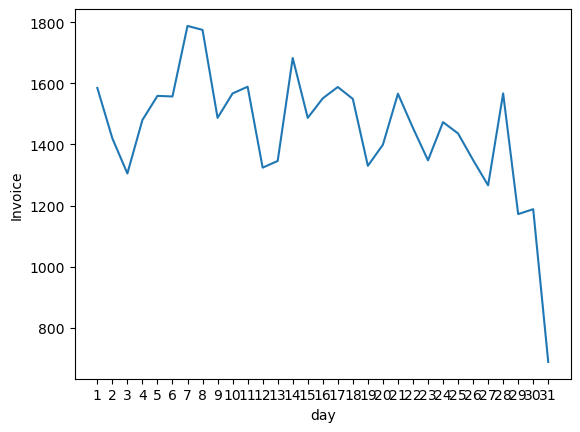

In [83]:
#orders over time 
date_wise_trends(df, "day", on = "Invoice", metric = "nunique")